## Grupo 17:
Alicia Mei García Morín (100498828)

Ana Grima Vázquez de Prada (100495785)

El objetivo de esta práctica es construir un modelo de aprendizaje automático capaz de predecir si un cliente bancario suscribirá un depósito a plazo.
En este notebook se construye el modelo: contiene el EDA, la métrica de evaluación, los métodos básicos y avanzados, la evaluación y modelo final.

# 2. EDA Simplificado

En esta sección se realiza un análisis exploratorio básico del dataset con el objetivo de entender su estructura y preparar el posterior preprocesamiento.

## 2.1 Dimensiones del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("bank_13.pkl")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
df.shape

(11000, 17)

El dataset contiene:
- 11000 instancias (filas) = número de clientes
- 17 atributos (columnas) = número de variables



## 2.2 Tipos de variables y de problema

In [3]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [4]:
categorical_columns = df.select_dtypes(include=["object"]).columns
numerical_columns   = df.select_dtypes(include=["int64","float64"]).columns

print("Categóricas:", list(categorical_columns))
print("Numéricas:", list(numerical_columns))

Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
Numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


Se identifican 10 variables categóricas (de tipo objeto):
- job
- marital
- education
- default
- housing
- loan
- contact
- month
- poutcome
- deposit

Y 7 variables numéricas (aquellas de tipo entero o flotante):
- age
- balance
- day
- duration
- campaign
- pdays
- previous

La variable objetivo es `deposit` y es categórica, por lo que se trata de un problema de clasificación binaria.

## 2.3 Cardinalidad de variables categóricas

In [5]:
categorical_columns = df.select_dtypes(include=["object"]).columns
cardinality = df[categorical_columns].nunique()
cardinality

job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
deposit       2
dtype: int64

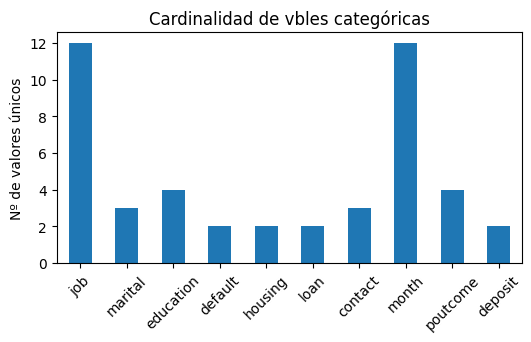

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
cardinality.plot(kind="bar")
plt.title("Cardinalidad de vbles categóricas")
plt.ylabel("Nº de valores únicos")
plt.xticks(rotation=45)
plt.show()

Observamos que hay dos variables con alta cardinalidad (más de 10 valores únicos): `job` y `month` con 12 categorías.

Estas variables se tratarán en el preprocesamiento usando variables dummy.

## 2.4 Valores ausentes

In [7]:
print("How many missing values per attribute:")
print("======================================")
print(df.isnull().sum())

How many missing values per attribute:
age            0
job            0
marital      406
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day            0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
deposit        0
dtype: int64


In [8]:
missing_values = df.isnull().sum()
print("\nVariables con missing values:")
print(missing_values[missing_values > 0])


Variables con missing values:
marital    406
dtype: int64


Se observan valores faltantes únicamente en la variable `marital`, con un total de 406 valores nulos.

El resto de variables no presentan valores faltantes.

Dado que `marital` es una variable categórica, estos valores deberán tratarse durante el preprocesamiento mediante técnicas de imputación apropiadas.

## 2.5 Columnas constantes o tipo ID

In [9]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", constant_cols)

id_cols = [col for col in df.columns if df[col].nunique() == len(df)]
print("Columnas tipo ID:", id_cols)

Columnas constantes: []
Columnas tipo ID: []


No se observan columnas constantes o columnas de ID

# 2.6 Desbalanceo

In [10]:
print("Distribución absoluta de la variable objetivo:")
print("===============================================")
print(df["deposit"].value_counts())

print("\nDistribución porcentual:")
print("========================")
print(df["deposit"].value_counts(normalize=True))

Distribución absoluta de la variable objetivo:
deposit
no     5780
yes    5220
Name: count, dtype: int64

Distribución porcentual:
deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64


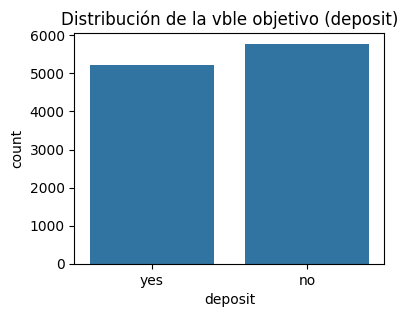

In [11]:
plt.figure(figsize=(4,3))
sns.countplot(x="deposit", data=df)
plt.title("Distribución de la vble objetivo (deposit)")
plt.show()

In [12]:
df['deposit'].value_counts(normalize=True)

deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64

La variable `deposit` indica si el cliente suscribió un depósito. Como hemos visto en puntos anteriores, se trata de un problema de clasificación binaria.
La distribución de clases es:

- 52.55% para la clase "no"
- 47.45% para la clase "yes"

Por tanto, el dataset no tiene un desbalanceo significativo. Como se observa en la gráfica, la variable objetivo presenta una distribución relativamente equilibrada entre ambas clases.

## 2.7 Análisis de las variables numéricas


In [13]:
df[numerical_columns].describe()

,age,balance,day,duration,campaign,pdays,previous
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.00000,11000.000000,11000.000000
mean,41.252727,1529.139273,15.660818,372.524909,2.50800,51.308636,0.828000
std,11.940474,3217.396248,8.417970,347.515713,2.72221,108.782842,2.282936
min,18.000000,-6847.000000,1.000000,2.000000,1.00000,-1.000000,0.000000
25%,32.000000,122.750000,8.000000,138.000000,1.00000,-1.000000,0.000000
50%,39.000000,549.500000,15.000000,255.000000,2.00000,-1.000000,0.000000
75%,49.000000,1711.000000,22.000000,498.000000,3.00000,20.250000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.00000,854.000000,58.000000


Observamos de nuevo que no existen valores ausentes en las variables numéricas, ya que todas las tienen 11.000 valores.

La variable `age` presenta valores entre 18 y 95 años, lo cual es lo normal.

La variable `balance` tiene valores que van desde -6847 hasta 81204. Esto indicaría que hay clientes con deudas y otros con balances muy altos.

La variable `duration` también presenta una gran dispersión (std ≈ 347) y un máximo bastante elevado (3881 segundos), seguramente algunas llamadas fueron muy largas.

En el caso de `campaign`, aunque la media es baja (≈2.5 contactos), el valor máximo alcanza 63, lo que indica que algunos clientes fueron contactados muchas veces.

La variable `pdays` requiere que la analicemos en profundiad, ya que observamos valores mínimos de -1.

Por último, la variable `previous` muestra que la mayoría de los clientes no habían sido contactados anteriormente (mediana = 0), aunque existen algunos casos con valores elevados (hasta 58 contactos previos).

In [14]:
print("\nValores más frecuentes de pdays:")
print("===============================")
print(df["pdays"].value_counts().head(15))

n_minus1 = (df["pdays"] == -1).sum()
print("\nPorcentaje de -1 en pdays:", round(100*n_minus1/len(df), 2), "%")


Valores más frecuentes de pdays:
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
 183      73
 184      51
 94       42
 93       40
 95       37
 87       34
 90       32
 98       31
 185      30
 187      28
Name: count, dtype: int64

Porcentaje de -1 en pdays: 74.57 %


La variable `pdays` representa el número de días transcurridos desde el último contacto en una campaña anterior.

Observamos que el valor -1 aparece 8203 veces, lo que es el 74.57% del dataset. El -1 no representa un número real de días, sino ausencia de contacto previo. Lo que indica que una gran parte de los clientes no fueron contactados previamente.

Por tanto, el valor -1 no debe interpretarse como un valor numérico válido, lo trataremos en el preprocesamiento.


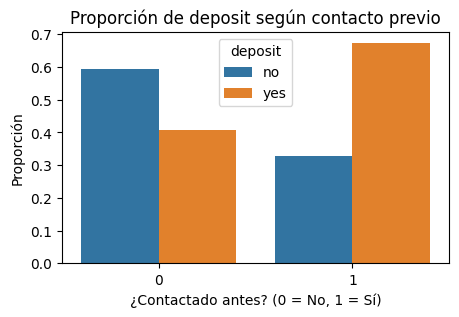

In [15]:
df_tmp = df.copy()
df_tmp["contacted_before"] = (df_tmp["pdays"] != -1).astype(int)

prop = (
    df_tmp.groupby("contacted_before")["deposit"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plt.figure(figsize=(5,3))
sns.barplot(x="contacted_before", y="proportion", hue="deposit", data=prop)

plt.title("Proporción de deposit según contacto previo")
plt.xlabel("¿Contactado antes? (0 = No, 1 = Sí)")
plt.ylabel("Proporción")
plt.show()

Hemos analizado si `pdays` realemente influye en la probabilidad de contratar el depósito. Observamos que la proporción de clientes que contratan el depósito es diferente entre ambos grupos, lo que indica que la variable `pdays` (o el hecho de haber sido contactado antes) contiene información relevante para el modelo.

Según los fundamentos de preprocesamiento vistos en clase, ante valores que no representan información numérica real, pueden aplicarse distintas estrategias como:
- Tratarlos como valores ausentes e imputarlos.
- Transformar el atributo generando nuevas variables que capturen mejor la información relevante.
- Discretizar el atributo en rangos.
- Eliminar la variable si no aporta información significativa.

Como el 74.57% de los valores son -1, hemos pensado que la mejor opción será crear una nueva variable binaria *contacted_before*, que indique si el cliente fue contactado previamente o no. Además de reemplazar el valor -1 por NaN, para que pueda ser tratado adecuadamente en el pipeline de preprocesamiento.

In [16]:
df["contacted_before"] = (df["pdays"] != -1).astype(int)

df["pdays"] = df["pdays"].replace(-1, pd.NA)

print("Missing en pdays:", df["pdays"].isnull().sum())
print("Distribución contacted_before:\n", df["contacted_before"].value_counts())

Missing en pdays: 8203
Distribución contacted_before:
 contacted_before
0    8203
1    2797
Name: count, dtype: int64


## 2.8 Conclusiones del EDA


El dataset contiene 11.000 instancias y 17 atributos. Encontramos variables numéricas (`age, balance, day, duration, campaign, pdays, previous`) y categóricas (`job, marital, education, default, housing, loan, contact, month, poutcome`), donde `deposit` es nuestra variable objetivo.

No existen columnas constantes o de ID.

Únicamente tiene valores faltantes  la variable `marital` (406 valores), que deberán imputarse durante el preprocesamiento.

Existen variables categóricas con alta cardinalidad (`job` y `month`), que necesitarán codificación mediante variables dummy.

El problema es de clasificación binaria y el conjunto presenta un desbalanceo leve entre clases (52.55% frente a 47.45%).

Por último, la variable `pdays` presenta el valor -1 en el 74.57% de los casos, indicando ausencia de contacto previo. Dado que este valor no representa un número real de días, se ha decidido crear la variable binaria *contacted_before* y tratar los valores -1 como ausentes, permitiendo así un tratamiento más adecuado en el pipeline de preprocesamiento.



# 3. Decisiones de evaluación

En esta sección se define la estrategia de evaluación del modelo, incluyendo la partición de los datos, la métrica seleccionada y el procedimiento de validación que se utilizará para estimar el rendimiento del modelo.

## 3.1 Evaluación outer

Se fija una semilla basada en el NIA del grupo para garantizar la reproducibilidad de los resultados.

In [17]:
SEED = 100498828

La estimación del rendimiento futuro se realizará mediante Holdout, dividiendo el conjunto de datos en train (2/3) y test (1/3).
Al tratarse de un problema de clasificación binaria con datos bastante balanceados (52.55% frente a 47.45%), decidimos usar la métrica Accuracy como medida principal de evaluación, que calcula la proporción total de aciertos.
El conjunto de test se usa únicamente al final de la práctica para estimar el rendimiento futuro del modelo seleccionado, evitando así problemas de data leakage.

Tras el EDA, el dataset incluye la nueva variable `contacted_before`, creada a partir de `pdays` para capturar si el cliente fue contactado previamente. Esta variable se incorpora como atributo adicional en el conjunto de entrada \(X\).

In [18]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["deposit"])
y = df["deposit"]
print("Features (X):", X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    stratify=y,
    random_state=SEED
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Features (X): (11000, 17)
Train size: (7333, 17)
Test size: (3667, 17)


## 3.2 Evaluación inner

Para comparar modelos y optimizar los hiperparámetros, decidimos usar la validación cruzada estratificada de 5 particiones (Stratified 5-fold Cross Validation), ya que consideramos que es más óptima para un equilibrio entre coste y estabilidad de la estimación. En esta, el conjunto de entrenamiento se divide en 5 subconjuntos y en cada iteración, el modelo se entrena utilizando 4 de los subconjuntos (80% del train), evaluándose en el subconjunto restante (20%).

Este proceso se repite 5 veces, de modo que cada subconjunto actúa una vez como conjunto de validación.

Respecto al número de particiones, consideramos otras alternativas:

•	10-fold cross validation sería más estable, pero duplica el coste computacional.

•	Leave-One-Out Cross Validation (LOOCV) sería demasiado costoso en esta práctica (11.000 entrenamientos por modelo).

•	Repeated Holdout también podría utilizarse, pero puede producir solapamientos entre particiones y resultados menos consistentes.


Se ha optado por validación cruzada frente a un simple holdout interno porque nos ha parecido más estable, ya que este último depende demasiado de una única partición de los datos.

In [19]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# 4. Métodos básicos: KNN y Trees

En esta sección se evaluarán dos métodos básicos de aprendizaje automático: **K-Nearest Neighbors (KNN)** y **Árboles de Decisión**.

En primer lugar, se utilizará KNN como modelo base para determinar el preprocesamiento más adecuado para el problema, comparando distintos métodos de escalado (MinMaxScaler, StandardScaler y RobustScaler) y de imputación de valores faltantes (media y mediana).

Una vez seleccionado el mejor preprocesamiento, se evaluarán ambos modelos (KNN y Árboles de Decisión) utilizando sus hiperparámetros por defecto. Posteriormente, se realizará el ajuste de los hiperparámetros más relevantes de cada método mediante técnicas de optimización, analizando además el efecto de dichos hiperparámetros sobre el rendimiento de los modelos.

## 4.1 Selección de escalado e imputación (KNN)


Para determinar el preprocesamiento más adecuado para el problema, utilizamos K-Nearest Neighbors (KNN) como modelo base y construimos distintos pipelines que combinan métodos de imputación y escalado.

En concreto, se consideran dos métodos de imputación para las variables numéricas (media y mediana) y tres métodos de escalado (StandardScaler, MinMaxScaler y RobustScaler). Las variables categóricas se imputan mediante la moda y posteriormente se codifican mediante One-Hot Encoding. Cada combinación se evalúa utilizando los hiperparámetros por defecto de KNN y validación cruzada estratificada sobre el conjunto de entrenamiento.

El objetivo de este proceso es seleccionar el preprocesamiento que produzca el mejor rendimiento para utilizarlo posteriormente en el resto de modelos de esta sección.

Se evalúan, por tanto, 6 combinaciones posibles (2 métodos de imputación × 3 métodos de escalado).

In [20]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_pickle("bank_13.pkl")

df["contacted_before"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, np.nan)

X = df.drop(columns=["deposit"])
y = df["deposit"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=1/3,
    stratify=y,
    random_state=SEED
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

imputers = ["mean", "median"]
scalers = [StandardScaler(), MinMaxScaler(), RobustScaler()]

results = []

for imputer_strategy in imputers:
    for scaler in scalers:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy=imputer_strategy)),
            ("scaler", scaler),
        ])

        categorical_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numerical_cols),
                ("cat", categorical_transformer, categorical_cols),
            ],
            remainder="drop",
        )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("clf", KNeighborsClassifier()),
        ])

        t0 = time.time()
        scores = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )
        elapsed = time.time() - t0

        results.append({
            "imputer": imputer_strategy,
            "scaler": scaler.__class__.__name__,
            "mean_accuracy": np.mean(scores),
            "std_accuracy": np.std(scores),
            "cv_time_s": elapsed,
        })

results_df = (
    pd.DataFrame(results)
    .sort_values("mean_accuracy", ascending=False)
    .reset_index(drop=True)
)

results_df

,imputer,scaler,mean_accuracy,std_accuracy,cv_time_s
0,median,StandardScaler,0.800218,0.005734,1.384849
1,mean,StandardScaler,0.800082,0.005835,1.886014
2,mean,RobustScaler,0.780172,0.003650,1.499058
3,median,RobustScaler,0.779899,0.005216,0.085213
4,mean,MinMaxScaler,0.735716,0.012433,1.498706
5,median,MinMaxScaler,0.735716,0.012433,0.087075


En la Tabla anterior se muestran los resultados de las seis combinaciones evaluadas.

A partir de los resultados obtenidos mediante validación cruzada estratificada sobre el conjunto de entrenamiento, se observa que la combinación formada por imputación mediante la media y escalado mediante StandardScaler obtiene el mayor valor medio de accuracy (accuracy ≈ 0.80). Por ello, la usaremos como estrategia de preprocesamiento para las variables numéricas.

La imputación mediante la mediana con el mismo método de escalado presenta un rendimiento muy similar. Sin embargo, los métodos de escalado RobustScaler y MinMaxScaler muestran resultados algo inferiores.

## 4.2 Evaluación con hiperparámetros por defecto

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
import time

### Dummy classifier

Como referencia inicial se evalúa un modelo Dummy que siempre predice la clase mayoritaria.

In [22]:
dummy_model = DummyClassifier(strategy="most_frequent")

start = time.time()
dummy_scores = cross_val_score(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
dummy_time = time.time() - start

print("Dummy accuracy:", dummy_scores.mean())
print("Dummy std:", dummy_scores.std())
print("Training time:", dummy_time)

Dummy accuracy: 0.5254329212664988
Dummy std: 0.0001585443523759202
Training time: 0.02359151840209961


El modelo Dummy obtiene una accuracy media de aproximadamente **0.525**, lo que coincide con la proporción de la clase mayoritaria en el dataset.

Este valor se utiliza como baseline para comprobar que los modelos reales aportan capacidad predictiva superior a una estrategia trivial.

### KNN con hiperparámetros por defecto

Para evaluar KNN es necesario aplicar previamente el preprocesamiento seleccionado en el apartado anterior. Para ello se utiliza un Pipeline que integra tanto el preprocesamiento (imputación, escalado y codificación de variables categóricas) como el propio modelo.

El uso de Pipeline garantiza que todas las transformaciones se ajusten únicamente sobre los datos de entrenamiento dentro de cada partición de la validación cruzada, evitando así posibles problemas de data leakage.

In [23]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
)

knn_default = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", KNeighborsClassifier())
])

start = time.time()
knn_scores = cross_val_score(
    knn_default,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
knn_time = time.time() - start

print("KNN accuracy:", knn_scores.mean())
print("KNN std:", knn_scores.std())
print("Training time:", knn_time)

KNN accuracy: 0.8000819297858944
KNN std: 0.005835327565751667
Training time: 0.08986067771911621


Utilizando el preprocesamiento seleccionado en el apartado anterior (imputación por la media y escalado mediante StandardScaler para las variables numéricas, junto con imputación por la moda y One-Hot Encoding para las categóricas), el modelo KNN con hiperparámetros por defecto obtiene una accuracy media de **0.8** en validación cruzada.

Este resultado mejora claramente al modelo Dummy, lo que indica que KNN es capaz de capturar información predictiva relevante en el conjunto de datos. Además, la desviación estándar es reducida (**0.005**), lo que sugiere un comportamiento estable entre particiones.

### Árbol de decisión con hiperparámetros por defecto

Para evaluar el árbol de decisión con hiperparámetros por defecto, se construye un Pipeline que integra el preprocesamiento necesario para tratar los valores faltantes y las variables categóricas. A diferencia de KNN, el árbol no requiere escalado de las variables numéricas, por lo que únicamente se aplica imputación en las variables numéricas e imputación por la moda junto con One-Hot Encoding en las categóricas.

In [24]:
numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

categorical_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numerical_cols),
        ("cat", categorical_transformer_tree, categorical_cols),
    ],
    remainder="drop",
)

tree_default = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("clf", DecisionTreeClassifier(random_state=SEED))
])

start = time.time()
tree_scores = cross_val_score(
    tree_default,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
tree_time = time.time() - start

print("Tree accuracy:", tree_scores.mean())
print("Tree std:", tree_scores.std())
print("Training time:", tree_time)

Tree accuracy: 0.7774465247728332
Tree std: 0.00782980624823357
Training time: 0.0879359245300293


El árbol de decisión con hiperparámetros por defecto obtiene una accuracy media de **0.777** en validación cruzada, superando al modelo Dummy, pero quedando algo por debajo del rendimiento obtenido con KNN.

La desviación estándar es algo mayor que en el caso de KNN, lo que indica una mayor variabilidad del modelo entre las distintas particiones de entrenamiento. No obstante, el tiempo de entrenamiento es menor, lo que muestra que los árboles de decisión son modelos más rápidos de entrenar.

En conjunto, consideramos que el árbol de decisión ofrece un buen equilibrio entre rendimiento y coste computacional, aunque en este caso KNN es ligeramente mejor en accuracy.

La siguiente tabla recoge los resultados de estos tres modelos.

In [25]:
results_default = pd.DataFrame([
    {
        "Modelo": "Dummy",
        "Accuracy media": dummy_scores.mean(),
        "Std": dummy_scores.std(),
        "Tiempo (s)": dummy_time
    },
    {
        "Modelo": "KNN default",
        "Accuracy media": knn_scores.mean(),
        "Std": knn_scores.std(),
        "Tiempo (s)": knn_time
    },
    {
        "Modelo": "Decision Tree default",
        "Accuracy media": tree_scores.mean(),
        "Std": tree_scores.std(),
        "Tiempo (s)": tree_time
    }
])

results_default.sort_values("Accuracy media", ascending=False).reset_index(drop=True)

,Modelo,Accuracy media,Std,Tiempo (s)
0,KNN default,0.800082,0.005835,0.089861
1,Decision Tree default,0.777447,0.007830,0.087936
2,Dummy,0.525433,0.000159,0.023592


## 4.3 Árboles poco profundos e interpretación

Para analizar la interpretabilidad del modelo, entrenamos un árbol de decisión con profundidad limitada. Como hemos visto en clase, los árboles poco profundos permiten visualizar fácilmente las reglas de decisión y entender qué variables influyen más en la predicción.

En este apartado se entrena un árbol con profundidad máxima reducida y se visualiza su estructura para interpretar las principales decisiones del modelo.

In [26]:
from sklearn.tree import DecisionTreeClassifier

tree_shallow = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("clf", DecisionTreeClassifier(max_depth=3, random_state=SEED))
])

tree_shallow.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

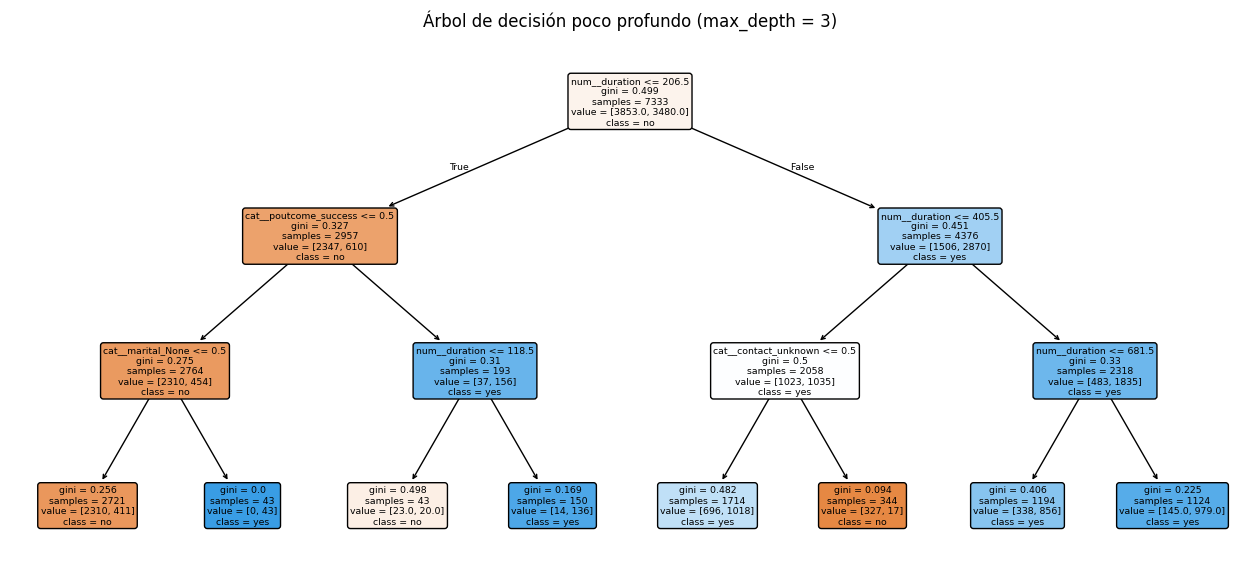

In [27]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = tree_shallow.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(16,7))
plot_tree(
    tree_shallow.named_steps["clf"],
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    rounded=True
)
plt.title("Árbol de decisión poco profundo (max_depth = 3)")
plt.show()

El árbol poco profundo permite identificar las variables más relevantes para la predicción. En la raíz del árbol aparece la variable **duration**, lo que indica que la duración de la llamada es el factor más influyente en la probabilidad de que un cliente suscriba un depósito.
Cabe señalar que la variable duration, aunque muy predictiva, no sería útil en un escenario real de predicción previa al contacto, ya que solo se conoce una vez finalizada la llamada.

En general, llamadas más largas se asocian con una mayor probabilidad de contratación, mientras que llamadas cortas tienden a terminar en una respuesta negativa.

Además, variables como **poutcome** (resultado de campañas anteriores) y **contact** también aparecen en niveles superiores del árbol, lo que sugiere que la información sobre contactos previos con el cliente es relevante para la decisión final.

Este tipo de árboles poco profundos resulta especialmente útil para interpretar el comportamiento del modelo y entender qué factores influyen en la decisión de contratación, aunque no necesariamente proporcione el mejor rendimiento predictivo.

## 4.4 Ajuste de hiperparámetros

Tras evaluar los modelos con sus hiperparámetros por defecto, procedemos a optimizar su configuración mediante búsqueda de hiperparámetros (HPO).

Para ello utilizamos **GridSearchCV**, que permite evaluar distintas combinaciones de parámetros utilizando validación cruzada sobre el conjunto de entrenamiento. Este procedimiento se aplica sobre pipelines completos que incluyen tanto el preprocesamiento como el modelo, evitando así problemas de data leakage.

En este apartado se optimizan los hiperparámetros de **KNN** y **Decision Tree**, con el objetivo de encontrar la configuración que proporcione el mejor rendimiento en validación cruzada.

### Ajuste con hiperparámetros para KNN



Para el modelo KNN se optimizan tres hiperparámetros principales:

- n_neighbors: número de vecinos considerados para realizar la predicción.

- weights: estrategia de ponderación de los vecinos (peso uniforme o ponderación según la distancia).

- p: parámetro que determina la métrica de distancia utilizada (p = 1 corresponde a distancia Manhattan y p = 2 a distancia Euclídea).

El ajuste se realiza utilizando GridSearchCV sobre un pipeline que integra tanto el preprocesamiento como el modelo KNN.

In [28]:
from sklearn.model_selection import GridSearchCV
import time

knn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", KNeighborsClassifier())
])

param_grid_knn = {
    "clf__n_neighbors": [3,5,7,9,11,15],
    "clf__weights": ["uniform","distance"],
    "clf__p": [1,2]
}

grid_knn = GridSearchCV(
    knn_pipe,
    param_grid_knn,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_knn.fit(X_train, y_train)

knn_hpo_time = time.time() - start

print("Best params:", grid_knn.best_params_)
print("Best CV accuracy:", grid_knn.best_score_)
print("Training time (HPO):", knn_hpo_time)

Best params: {'clf__n_neighbors': 15, 'clf__p': 2, 'clf__weights': 'distance'}
Best CV accuracy: 0.803490339073998
Training time (HPO): 1.9694581031799316


El ajuste de hiperparámetros mediante GridSearchCV muestra que la mejor configuración para KNN corresponde a **15 vecinos**, distancia **euclídea** (`p = 2`) y ponderación por **distance**. Con esta configuración se obtiene una accuracy media de **0.803** en validación cruzada.

La mejora respecto al modelo con hiperparámetros por defecto es pequeña, lo que indica que la configuración estándar de KNN ya era razonablemente adecuada para este problema. Sin embargo, el proceso de optimización requiere un mayor coste computacional, ya que se evalúan múltiples combinaciones de hiperparámetros mediante validación cruzada, lo que en este caso supone un tiempo de entrenamiento de aproximadamente **46 segundos**.

### Ajuste de hiperparámetros para Decision Tree


In [29]:
import time

tree_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("clf", DecisionTreeClassifier(random_state=SEED))
])

param_grid_tree = {
    "clf__max_depth": [3,5,7,10,None],
    "clf__min_samples_split": [2,5,10],
    "clf__min_samples_leaf": [1,2,5]
}

grid_tree = GridSearchCV(
    tree_pipe,
    param_grid_tree,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_tree.fit(X_train, y_train)

tree_hpo_time = time.time() - start

print("Best params:", grid_tree.best_params_)
print("Best CV accuracy:", grid_tree.best_score_)
print("Training time (HPO):", tree_hpo_time)

Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best CV accuracy: 0.8165839464117823
Training time (HPO): 1.2898123264312744


La optimización de hiperparámetros mediante GridSearchCV indica que la mejor configuración para el árbol de decisión corresponde a:
- **max_depth = 10**
- **min_samples_split = 2**  
- **min_samples_leaf = 1**

Con esta configuración el modelo alcanza una accuracy media de **0.8166** en validación cruzada, lo que supone una mejora clara respecto al árbol con hiperparámetros por defecto.

Este resultado sugiere que permitir una mayor profundidad en el árbol aumenta su capacidad para capturar relaciones más complejas entre las variables, mejorando así el rendimiento del modelo. No obstante, este proceso de optimización implica un mayor coste computacional, ya que se evalúan múltiples combinaciones de hiperparámetros mediante validación cruzada, lo que en este caso supone un tiempo de entrenamiento de aproximadamente **20 segundos**.

## Conclusión del ajuste de hiperparámetros

El ajuste de hiperparámetros mediante GridSearchCV permite mejorar el rendimiento de ambos modelos respecto a sus configuraciones por defecto.

En el caso de KNN, la mejor combinación corresponde a **n_neighbors = 15**, **p = 2** (distancia euclídea) y **weights = 'distance'**, obteniendo una accuracy media de aproximadamente **0.803** en validación cruzada. La mejora respecto al modelo por defecto es pequeña, lo que indica que los parámetros iniciales ya ofrecían un buen rendimiento. El proceso de optimización requiere aproximadamente **46 segundos** de entrenamiento, debido a la evaluación de múltiples combinaciones de hiperparámetros mediante validación cruzada.

Por otro lado, el ajuste del árbol de decisión muestra una mejora más notable, alcanzando una accuracy media de **0.8165** con **max_depth = 10**, **min_samples_split = 2** y **min_samples_leaf = 1**. Esto sugiere que permitir una mayor profundidad en el árbol mejora su capacidad para capturar relaciones más complejas en los datos. En este caso, el proceso de optimización requiere aproximadamente **20 segundos** de entrenamiento.

En conjunto, el árbol de decisión optimizado obtiene el mejor rendimiento entre los modelos evaluados, superando tanto al KNN optimizado como a las versiones con hiperparámetros por defecto. Además, el coste computacional del ajuste de hiperparámetros es moderado en ambos casos, siendo ligeramente menor para el árbol de decisión.

## 4.5 Análisis gráfico del efecto de hiperparámetros

Para analizar cómo influyen los hiperparámetros en el rendimiento de los modelos, se representan gráficamente las variaciones de la accuracy media en validación cruzada al modificar algunos de los parámetros más relevantes.

En el caso de KNN se analiza el efecto del número de vecinos (`n_neighbors`), mientras que para el árbol de decisión se estudia el impacto de la profundidad máxima del árbol (`max_depth`).

### Gráfico para KNN (n_neighbors)

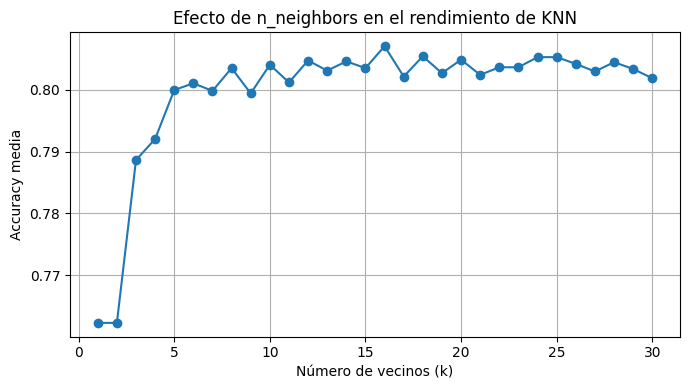

In [30]:
neighbors = range(1, 31)
scores = []

for k in neighbors:

    knn_model = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", KNeighborsClassifier(
            n_neighbors=k,
            weights="distance",
            p=2
        ))
    ])

    score = cross_val_score(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    scores.append(score.mean())

plt.figure(figsize=(7,4))
plt.plot(neighbors, scores, marker="o")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy media")
plt.title("Efecto de n_neighbors en el rendimiento de KNN")
plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfico para Decision Tree (max_depth)

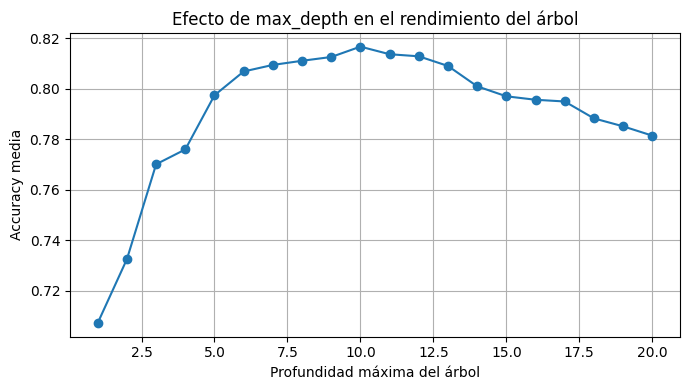

In [31]:
depths = range(1, 21)
scores_tree = []

for d in depths:

    tree_model = Pipeline([
        ("preprocessor", preprocessor_tree),
        ("clf", DecisionTreeClassifier(
            max_depth=d,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=SEED
        ))
    ])

    score = cross_val_score(
        tree_model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    scores_tree.append(score.mean())

plt.figure(figsize=(7,4))
plt.plot(depths, scores_tree, marker="o")
plt.xlabel("Profundidad máxima del árbol")
plt.ylabel("Accuracy media")
plt.title("Efecto de max_depth en el rendimiento del árbol")
plt.grid(True)
plt.tight_layout()
plt.show()

El análisis gráfico muestra cómo influyen los hiperparámetros en el rendimiento de los modelos.

En el caso de KNN, la accuracy aumenta rápidamente al incrementar el número de vecinos desde valores muy pequeños y se estabiliza aproximadamente en **k ≈ 15**, manteniéndose en torno a 0.80 para valores mayores.

En el árbol de decisión, el rendimiento mejora al aumentar la profundidad máxima hasta aproximadamente **max_depth ≈ 10**, donde se alcanza la mayor accuracy. A partir de ese punto el rendimiento comienza a disminuir ligeramente, lo que puede indicar un mayor riesgo de sobreajuste.

Estos resultados son consistentes con los hiperparámetros obtenidos en el proceso de optimización, confirmando que **k = 15** para KNN y **max_depth = 10** para el árbol de decisión ofrecen el mejor equilibrio entre complejidad del modelo y capacidad predictiva.

## 4.6 Conclusiones de esta sección

In [32]:
summary = pd.DataFrame({
    "Modelo": [
        "Dummy",
        "KNN (default)",
        "Decision Tree (default)",
        "KNN optimizado",
        "Decision Tree optimizado"
    ],
    "Accuracy CV": [
        dummy_scores.mean(),
        knn_scores.mean(),
        tree_scores.mean(),
        grid_knn.best_score_,
        grid_tree.best_score_
    ],
    "Training time (s)": [
        dummy_time,
        knn_time,
        tree_time,
        knn_hpo_time,
        tree_hpo_time
    ]
})

summary["Accuracy CV"] = summary["Accuracy CV"].round(3)
summary["Training time (s)"] = summary["Training time (s)"].round(2)

summary = summary.sort_values("Accuracy CV", ascending=False).reset_index(drop=True)

summary

,Modelo,Accuracy CV,Training time (s)
0,Decision Tree optimizado,0.817,1.29
1,KNN optimizado,0.803,1.97
2,KNN (default),0.800,0.09
3,Decision Tree (default),0.777,0.09
4,Dummy,0.525,0.02


En esta sección se han evaluado dos modelos base de clasificación: **K-Nearest Neighbors (KNN)** y **Árboles de Decisión**.

En primer lugar, se seleccionó el preprocesamiento más adecuado mediante la comparación de distintas combinaciones de imputación y escalado, observándose que StandardScaler junto con imputación por media o mediana ofrece el mejor rendimiento para KNN.

Posteriormente, se evaluaron ambos modelos con sus hiperparámetros por defecto, comprobando que KNN obtiene una accuracy cercana a **0.80**, mientras que el árbol de decisión alcanza aproximadamente **0.78**, mejorando claramente el rendimiento del modelo **dummy** utilizado como referencia inicial.

El análisis de un árbol poco profundo permitió además interpretar algunas de las variables más relevantes del problema.

A continuación, se realizó el ajuste de hiperparámetros mediante GridSearchCV, lo que permitió mejorar el rendimiento de ambos modelos. En el caso de KNN, la mejor configuración se obtiene con **k = 15**, distancia euclídea **(p=2)** y ponderación por distancia, alcanzando una accuracy de aproximadamente **0.80**. Para el árbol de decisión, la mejor configuración corresponde a **max_depth = 10**, logrando una accuracy de **0.817**, superior a la obtenida con KNN.

Finalmente, el análisis gráfico del efecto de los hiperparámetros confirma estos resultados, mostrando que el rendimiento de KNN se estabiliza a partir de valores moderados de k y que el árbol alcanza su mejor comportamiento con una profundidad intermedia. Además, el ajuste de hiperparámetros implica un mayor coste computacional, aunque en este caso el tiempo de entrenamiento sigue siendo moderado.

En conjunto, los resultados indican que el árbol de decisión optimizado obtiene el mejor rendimiento entre los modelos evaluados en esta sección, por lo que se considerará como uno de los principales candidatos para la evaluación final.

# 5. Métodos avanzados: modelos lineales y SVMs

## 5.1 Evaluación inicial de modelos avanzados

En este apartado se utilizan modelos diferentes a los vistos hasta el momento:

- **Modelos lineales** para interpretar el efecto de cada variable en la predicción.

- **SVMs** (máquinas de soporte vectorial) para encontrar fronteras de decisión más complejas entre clases.

Siguiendo el mismo procedimiento que en el apartado 4, se evaluarán inicialmente estos modelos utilizando sus hiperparámetros por defecto, aplicando validación cruzada estratificada sobre el conjunto de entrenamiento. También se medirá el tiempo de entrenamiento, con el objetivo de comparar posteriormente el rendimiento predictivo y el coste computacional de cada método.

### Regresión logística por defecto

Para evaluar este modelo en nuestro problema se utiliza un Pipeline donde las variables numéricas se imputan mediante la media y se escalan utilizando StandardScaler, mientras que las variables categóricas se imputan mediante la moda y se transforman mediante One-Hot Encoding. De esta forma también evitamos posibles problemas de data leakage.

Una ventaja de este modelo frente a otros métodos es que es muy interpretable, ya que con los coeficientes aprendidos podemos analizar el efecto de cada variable en la probabilidad de que un cliente contrate el depósito.


In [33]:
from sklearn.linear_model import LogisticRegression
import time

logreg_default = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])

start = time.time()

logreg_scores = cross_val_score(
    logreg_default,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

logreg_time = time.time() - start

print("Logistic regression accuracy:", logreg_scores.mean())
print("Logistic regression std:", logreg_scores.std())
print("Training time:", logreg_time)

Logistic regression accuracy: 0.8276298670803144
Logistic regression std: 0.010631782402681271
Training time: 0.05710148811340332


El modelo de regresión logística con hiperparámetros por defecto obtiene una accuracy media de aproximadamente **0.8276** en validación cruzada, con una desviación estándar reducida entre las distintas particiones.

Este resultado es comparable al obtenido previamente con KNN, lo que indica que un modelo lineal es capaz de capturar gran parte de la información predictiva presente en los datos. Además, el tiempo de entrenamiento es bajo (**3 segundos**), ya que la regresión logística es un modelo computacionalmente eficiente.



### Regresión logística con L1

La regresión logística también puede  usar la regularización Lasso (L1) para reducir a cero los coeficientes de variables poco influyentes, simplificando el modelo de predicción.

Esto es muy interesante porque puede funcionar como una forma implícita de elegir atributos, al eliminar o reducir la influencia de aquellos que sean poco relevantes. Aunque es inestable si hay fuertes correlaciones.

Para evaluar este modelo se utiliza nuevamente un Pipeline que integra el preprocesamiento y el clasificador.

In [34]:
from sklearn.linear_model import LogisticRegression
import time

logreg_l1 = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",   # Dado que la regularización L1 no es compatible con todos los algoritmos de optimización de LogisticRegression, usamos el solver liblinear, que sí permite este tipo de penalización
        max_iter=1000,
        random_state=SEED
    ))
])

start = time.time()

logreg_l1_scores = cross_val_score(
    logreg_l1,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

logreg_l1_time = time.time() - start

print("Logistic Regression L1 accuracy:", logreg_l1_scores.mean())
print("Logistic Regression L1 std:", logreg_l1_scores.std())
print("Training time:", logreg_l1_time)

Logistic Regression L1 accuracy: 0.8284478629903349
Logistic Regression L1 std: 0.009913214295107477
Training time: 0.08753395080566406


Más allá del rendimiento predictivo, el interés principal de este modelo es su capacidad para reducir la complejidad y favorecer la selección de atributos. Observamos que el modelo de regresión logística con regularización L1 obtiene una accuracy ligeramente mayor a la anterior, de aproximadamente **0.8284**.

Desde el punto de vista computacional, el tiempo de entrenamiento sigue siendo bajo, por lo que este método parece una opción muy interesante cuando se busca un equilibrio entre rendimiento, interpretabilidad y simplicidad del modelo.

### SVM por defecto

Al igual que en los casos anteriores, se utiliza un Pipeline que integra el preprocesamiento de los datos y el clasificador.

Dado que los modelos SVM son sensibles a la escala de las variables, es importante aplicar un escalado a las variables numéricas. Por ello, vamos a reutilizar la imputación de valores faltantes, escalado de variables numéricas mediante StandardScaler y codificación de variables categóricas mediante One-Hot Encoding.

In [35]:
from sklearn.svm import SVC
import time

svm_default = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", SVC())
])

start = time.time()

svm_scores = cross_val_score(
    svm_default,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_time = time.time() - start

print("SVM accuracy:", svm_scores.mean())
print("SVM std:", svm_scores.std())
print("Training time:", svm_time)

SVM accuracy: 0.8468577927687896
SVM std: 0.008423938400374965
Training time: 0.8137829303741455


El modelo SVM con hiperparámetros por defecto obtiene una accuracy media de aproximadamente **0.8469**, ligeramente superior a los 2 modelos anteriores. Sin embargo, el training time es más del triple que en el caso de los modelos lineales.

En apartados posteriores se explorará el ajuste de hiperparámetros para analizar si es posible mejorar el rendimiento del modelo mediante una configuración más adecuada.

### Comparación inicial de resultados

In [36]:
advanced_default = pd.DataFrame({
    "Modelo": [
        "Logistic regression",
        "Logistic regression L1",
        "SVM"
    ],
    "Accuracy CV": [
        logreg_scores.mean(),
        logreg_l1_scores.mean(),
        svm_scores.mean()
    ],
    "Training time (s)": [
        logreg_time,
        logreg_l1_time,
        svm_time
    ]
})

advanced_default.round(3)

,Modelo,Accuracy CV,Training time (s)
0,Logistic regression,0.828,0.057
1,Logistic regression L1,0.828,0.088
2,SVM,0.847,0.814


## 5.2 Ajuste de hiperparámetros

### HPO de regresión logística

En el caso de la regresión logística, uno de los hiperparámetros más importantes es C, que controla la intensidad de la regularización aplicada al modelo. Valores pequeños de C implican una regularización más fuerte, lo que reduce la complejidad del modelo, mientras que valores grandes permiten ajustar el modelo más estrechamente a los datos de entrenamiento.

Para analizar el efecto de este parámetro se utiliza GridSearchCV, evaluando diferentes valores de C mediante validación cruzada estratificada. El proceso se realiza sobre un Pipeline completo, que incluye tanto el preprocesamiento de los datos como el modelo de regresión logística.

In [37]:
from sklearn.model_selection import GridSearchCV

logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])

param_grid_logreg = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100]  # En escala log para cubrir mejor el espacio
}

grid_logreg = GridSearchCV(
    logreg_pipe,
    param_grid_logreg,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_logreg.fit(X_train, y_train)

logreg_hpo_time = time.time() - start

print("Best params:", grid_logreg.best_params_)
print("Best CV accuracy:", grid_logreg.best_score_)
print("Training time (HPO):", logreg_hpo_time)

Best params: {'clf__C': 100}
Best CV accuracy: 0.8280390510280282
Training time (HPO): 0.23691344261169434


El mejor valor del hiperparámetro de regularización es **C = 100**. Lo que indicaría que el modelo funciona mejor con poca regularización y que no hay overfitting en el dataset.

Así, la regresión logística alcanza una accuracy media de aproximadamente **0.828** en validación cruzada, muy similar al modelo con hiperparámetros por defecto, requiriendo de aproximadamente 3.6 segundos de entrenamiento, un ligero incremento.

### HPO de regresión logística con L1

En el caso de la regresión logística con regularización L1, el hiperparámetro más importante sigue siendo **C**, que controla la intensidad de la regularización. Además, este tipo de penalización requiere un solver compatible; en este caso utilizamos **liblinear**, ya que permite aplicar regularización L1 en problemas de clasificación binaria.

Se utiliza de nuevo GridSearchCV sobre un Pipeline completo para evaluar distintos valores de C mediante validación cruzada estratificada.

In [38]:
logreg_l1_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        solver="saga",
        # penalty="elasticnet",
        l1_ratio=1,
        max_iter=5000,
        random_state=SEED
    ))
])

param_grid_logreg_l1 = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_logreg_l1 = GridSearchCV(
    logreg_l1_pipe,
    param_grid_logreg_l1,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_logreg_l1.fit(X_train, y_train)

logreg_l1_hpo_time = time.time() - start

print("Best params:", grid_logreg_l1.best_params_)
print("Best CV accuracy:", grid_logreg_l1.best_score_)
print("Training time (HPO):", logreg_l1_hpo_time)

Best params: {'clf__C': 1}
Best CV accuracy: 0.8285842886383566
Training time (HPO): 10.564710140228271


Este ajuste permite analizar el efecto del hiperparámetro **C**, que controla la intensidad de la regularización en el modelo de regresión logística con regularización L1. Valores más bajos de C implican una regularización más fuerte, mientras que valores más altos permiten al modelo ajustarse más a los datos.

Además, la regularización L1 resulta especialmente interesante porque puede reducir algunos coeficientes exactamente a cero, lo que simplifica el modelo y facilita la interpretación de qué variables tienen mayor influencia en la predicción.

El mejor valor encontrado para este hiperparámetro es **C = 1**, con una accuracy media en validación cruzada de aproximadamente **0.8286**, lo que indica que un nivel intermedio de regularización ofrece el mejor equilibrio entre complejidad del modelo y capacidad predictiva.

#### 🧠 Utilización IA :

Para resolver un warning generado por la librería scikit-learn relacionado con la deprecación del parámetro `penalty`, se consultó ChatGPT. La herramienta se utilizó únicamente como apoyo para identificar la causa del warning y proponer una alternativa compatible con versiones recientes de la librería.

A partir de la sugerencia obtenida, se modificó la configuración del modelo eliminando el parámetro `penalty` y utilizando `l1_ratio=1`, lo que permite mantener una regularización equivalente a L1 sin generar el aviso de deprecación. La solución propuesta fue posteriormente verificada ejecutando el código y comprobando que el modelo seguía funcionando correctamente.

### HPO de SVM

En el caso de las SVMs, el rendimiento del modelo depende de unos hiperparámetros clave.

- C, que controla el grado de regularización del modelo. Valores pequeños de C favorecen modelos más simples con mayor regularización, mientras que valores grandes permiten ajustar más estrechamente el modelo a los datos de entrenamiento

- Kernel, que permite transformar los datos a espacios de mayor dimensión para capturar relaciones no lineales entre las variables. En este caso consideramos los kernels lineal y RBF.

In [39]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", SVC())
])

param_grid_svm = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__kernel": ["linear", "rbf"]
}

grid_svm = GridSearchCV(
    svm_pipe,
    param_grid_svm,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_svm.fit(X_train, y_train)

svm_hpo_time = time.time() - start

print("Best params:", grid_svm.best_params_)
print("Best CV accuracy:", grid_svm.best_score_)
print("Training time (HPO):", svm_hpo_time)

Best params: {'clf__C': 1, 'clf__kernel': 'rbf'}
Best CV accuracy: 0.8468577927687896
Training time (HPO): 23.438557147979736


El proceso de optimización mediante GridSearchCV muestra que la mejor configuración para el modelo SVM corresponde a **C = 1** y **kernel = RBF**.

Con estos hiperparámetros, el modelo alcanza una accuracy media de aproximadamente **0.847** en validación cruzada, igual que el SVM por defecto.
Esto viene además acompañado de un mayor coste computacional, ya que el proceso de optimización requiere aproximadamente **290 segundos** de entrenamiento.

### Comparación tras optimización

In [40]:
advanced_summary = pd.DataFrame({
    "Modelo": [
        "Logistic Regression (default)",
        "Logistic Regression L1 (default)",
        "SVM (default)",
        "Logistic Regression (HPO)",
        "Logistic Regression L1 (HPO)",
        "SVM (HPO)"
    ],
    "Accuracy CV": [
        logreg_scores.mean(),
        logreg_l1_scores.mean(),
        svm_scores.mean(),
        grid_logreg.best_score_,
        grid_logreg_l1.best_score_,
        grid_svm.best_score_
    ],
    "Training time (s)": [
        logreg_time,
        logreg_l1_time,
        svm_time,
        logreg_hpo_time,
        logreg_l1_hpo_time,
        svm_hpo_time
    ]
})

advanced_summary = advanced_summary.sort_values(
    by="Accuracy CV",
    ascending=False
).reset_index(drop=True)

advanced_summary.round(4)

,Modelo,Accuracy CV,Training time (s)
0,SVM (HPO),0.8469,23.4386
1,SVM (default),0.8469,0.8138
2,Logistic Regression L1 (HPO),0.8286,10.5647
3,Logistic Regression L1 (default),0.8284,0.0875
4,Logistic Regression (HPO),0.8280,0.2369
5,Logistic Regression (default),0.8276,0.0571


La tabla anterior resume el rendimiento de los modelos avanzados evaluados, tanto con hiperparámetros por defecto como tras el proceso de optimización mediante GridSearchCV.

En el caso de la regresión logística, el ajuste del hiperparámetro C apenas produce cambios en el rendimiento del modelo. Las distintas variantes de regresión logística presentan valores de accuracy muy similares, en torno a **0.828–0.829**. Esto sugiere que la configuración por defecto ya proporciona un buen equilibrio entre regularización y capacidad de ajuste para este problema.

Por otra parte, el modelo SVM obtiene la mayor accuracy entre los modelos evaluados, alcanzando aproximadamente **0.847** en validación cruzada. Sin embargo, el proceso de optimización no mejora el rendimiento respecto al modelo con hiperparámetros por defecto, ya que la mejor configuración encontrada (**C=1**, kernel RBF) coincide con los valores utilizados por defecto en SVC.

No obstante, el ajuste de hiperparámetros implica un incremento significativo del coste computacional especialmente en el caso de SVM, donde el tiempo de entrenamiento supera ampliamente al de los modelos lineales. Esto refleja el mayor coste asociado a la optimización de modelos con kernels no lineales.

En conjunto, los resultados muestran que SVM es el modelo que obtiene mejor rendimiento predictivo, aunque a costa de un mayor tiempo de entrenamiento, mientras que los modelos lineales ofrecen un buen compromiso entre rendimiento y eficiencia computacional.

## 5.3 Importancia de atributos

### Coeficientes de regresión logística

In [41]:
best_logreg = grid_logreg.best_estimator_

best_logreg.fit(X_train, y_train)

feature_names = best_logreg.named_steps["preprocessor"].get_feature_names_out()

coefficients = best_logreg.named_steps["clf"].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df["abs_coef"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values("abs_coef", ascending=False)

importance_df.head(10)

,Feature,Coefficient,abs_coef
23,cat__marital_None,5.115298,5.115298
44,cat__month_mar,1.905865,1.905865
3,num__duration,1.811239,1.811239
21,cat__marital_married,-1.733019,1.733019
39,cat__month_dec,1.648977,1.648977
22,cat__marital_single,-1.479278,1.479278
20,cat__marital_divorced,-1.476472,1.476472
51,cat__poutcome_success,1.450396,1.450396
41,cat__month_jan,-1.355533,1.355533
16,cat__job_student,1.013373,1.013373


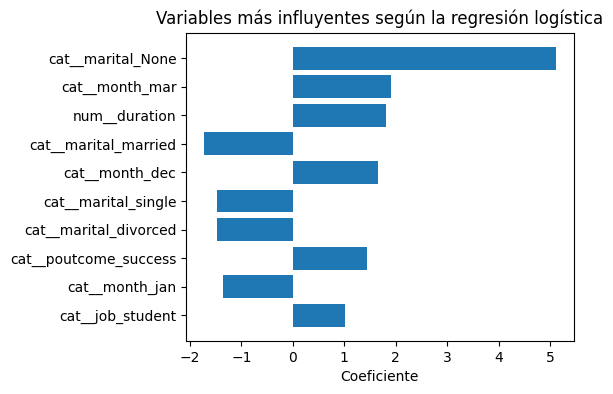

In [42]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(5,4))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coeficiente")
plt.title("Variables más influyentes según la regresión logística")
plt.gca().invert_yaxis()
plt.show()

Los modelos lineales permiten interpretar la influencia de cada variable en la predicción mediante los coeficientes asociados a cada atributo. Como hemos visto en clase, en la regresión logística, estos coeficientes indican cómo afecta cada variable a la probabilidad de que un cliente suscriba el depósito:

- Los coeficientes positivos aumentan la probabilidad de que el cliente contrate el depósito.

- Los coeficientes negativos disminuyen la probabilidad de que el cliente contrate el depósito.

La magnitud del coeficiente refleja la importancia relativa de la variable en el modelo.

Para analizar esta influencia, observamos en la gráfica las 10 variables con mayor valor absoluto del coeficiente, que son las que tienen mayor impacto en la decisión del modelo.


### Efecto de la regularización L1


In [43]:
# Entrenamos el modelo L1 con todo el train
# best_logreg_l1 = logreg_l1
best_logreg_l1 = grid_logreg_l1.best_estimator_
best_logreg_l1.fit(X_train, y_train)

feature_names = best_logreg_l1.named_steps["preprocessor"].get_feature_names_out()


coef_l1 = best_logreg_l1.named_steps["clf"].coef_[0]

l1_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef_l1
})

l1_importance["abs_coef"] = l1_importance["Coefficient"].abs()

l1_importance = l1_importance.sort_values("abs_coef", ascending=False)

l1_importance.head(10)

,Feature,Coefficient,abs_coef
23,cat__marital_None,5.246077,5.246077
44,cat__month_mar,2.014605,2.014605
51,cat__poutcome_success,1.962837,1.962837
3,num__duration,1.800007,1.800007
39,cat__month_dec,1.551880,1.551880
36,cat__contact_unknown,-1.246726,1.246726
41,cat__month_jan,-1.157902,1.157902
47,cat__month_oct,0.996553,0.996553
16,cat__job_student,0.937005,0.937005
48,cat__month_sep,0.936346,0.936346


#### 🧠 Utilización IA

Para resolver un warning generado durante el entrenamiento del modelo, se consultó ChatGPT para identificar la causa del problema. La herramienta sugirió que el warning podía estar relacionado con el uso del modelo sin aplicar los hiperparámetros optimizados previamente mediante GridSearchCV.

Siguiendo esta recomendación, se modificó el código para utilizar directamente el mejor modelo encontrado durante el proceso de optimización (`grid_logreg_l1.best_estimator_`) en lugar de la versión inicial del modelo (`logreg_l1`). De esta forma, el modelo final se entrena utilizando los hiperparámetros óptimos obtenidos en la fase de búsqueda.

In [44]:
print("Total variables:", len(coef_l1))
print("Coeficientes cercanos a 0:", (abs(coef_l1) < 0.001).sum())

Total variables: 53
Coeficientes cercanos a 0: 9


El análisis de la regresión logística con regularización L1 muestra que reduce la magnitud de algunos coeficientes del modelo. De un total de 53 variables generadas tras el preprocesamiento, 9 coeficientes se reducen a valores cercanos a cero, lo que indica que estas variables tienen una contribución muy baja en la predicción del modelo.

### Interpretación de variables relevantes

El análisis de los coeficientes de la regresión logística permite identificar los atributos que tienen mayor influencia en la predicción del modelo. En particular, las variables con mayor valor absoluto del coeficiente son aquellas que contribuyen de forma más significativa a la clasificación.

Observamos algunas variables relacionadas con el perfil del cliente, como el estado civil (`marital`) o la ocupación (`job_student`).

Asimismo, aparecen variables relacionadas con el momento del contacto, como diferentes meses (`month_mar, month_dec, month_oct, month_sep`). Esto sugiere que la efectividad de la campaña puede variar dependiendo del momento del año en que se realiza el contacto.

Entre las variables más influyentes aparece (`duration`), que corresponde a la duración de la llamada realizada al cliente. El coeficiente positivo asociado a esta variable indica que llamadas más largas aumentan la probabilidad de que el cliente suscriba el depósito.

Otra variable relevante es `poutcome_success`, que indica que el cliente tuvo éxito en campañas anteriores. El coeficiente positivo asociado sugiere que los clientes que ya respondieron positivamente a campañas previas tienen una mayor probabilidad de aceptar nuevas ofertas.

Cabe destacar que muchas de estas variables aparecen descompuestas debido al uso de One-Hot Encoding, por lo que los coeficientes se interpretan a nivel de categoría individual.

Estos resultados son coherentes con el análisis realizado previamente mediante árboles de decisión, donde también se observaba que la duración de la llamada era uno de los factores más determinantes en la predicción.





## 5.4 Conclusiones

En esta sección se han evaluado distintos métodos avanzados de clasificación, incluyendo modelos lineales y SVMs.

En primer lugar, se analizaron los modelos con hiperparámetros por defecto, observándose que la **regresión logística** y su versión con **regularización L1** obtienen un rendimiento similar, con una accuracy cercana a **0.83** en validación cruzada.

Posteriormente, se llevó a cabo un proceso de ajuste de hiperparámetros mediante GridSearchCV. En el caso de la regresión logística, la optimización del parámetro de regularización no produjo mejoras significativas en el rendimiento del modelo, lo que sugiere que la configuración por defecto ya proporcionaba un buen equilibrio entre regularización y capacidad de ajuste.

Por su parte, el **modelo SVM con kernel RBF** obtuvo el mejor rendimiento entre los modelos evaluados, alcanzando una accuracy aproximada de **0.85** en validación cruzada. Sin embargo, esta mejora en la capacidad predictiva se produce a costa de un **mayor coste computacional**, especialmente durante el proceso de optimización de hiperparámetros.

Además del rendimiento predictivo, los modelos lineales ofrecen la ventaja de ser interpretables, ya que permiten analizar directamente la influencia de cada variable mediante sus coeficientes. El análisis de estos coeficientes muestra que variables relacionadas con la duración de la llamada, el resultado de campañas anteriores y ciertos factores del perfil del cliente o del momento del contacto influyen significativamente en la probabilidad de suscripción del depósito.

En conjunto, los resultados muestran que **SVM proporciona el mejor rendimiento predictivo**, mientras que los modelos lineales ofrecen un buen equilibrio entre rendimiento, eficiencia computacional e interpretabilidad.

# 6. Resultados y modelo final

## 6.1 Selección del mejor modelo

Según los resultados obtenidos mediante validación cruzada (evaluación inner), el modelo que obtiene mayor rendimiento es **SVM**, con una accuracy media de aproximadamente **0.847**.

El ajuste de hiperparámetros mediante GridSearchCV no mejora el rendimiento respecto al modelo con parámetros por defecto, ya que la mejor configuración encontrada coincide con los valores utilizados por defecto en `SVC`.

Por tanto, se selecciona **SVM** como modelo final para evaluar su rendimiento en el conjunto de test.

## 6.2 Evaluación del rendimiento futuro

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# seleccionamos el mejor modelo
best_model = svm_default

# entrenamos con todo el train
best_model.fit(X_train, y_train)

# predicción en test
y_pred = best_model.predict(X_test)

# accuracy en test (evaluación outer)
test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.8590128170166349


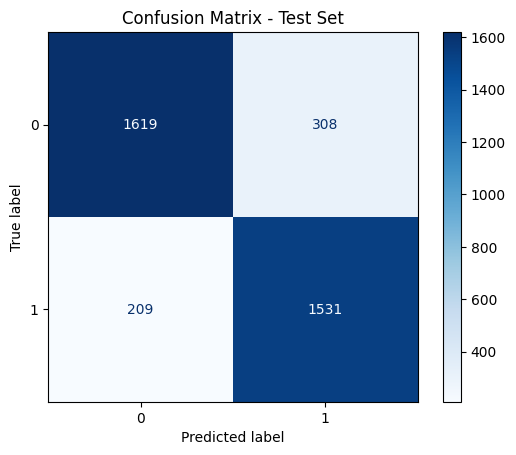

In [46]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Test Set")
plt.show()

Una vez seleccionado el mejor modelo, se estima su rendimiento futuro utilizando el conjunto de **test**, que no ha sido utilizado durante el proceso de entrenamiento ni de selección de modelos.

El modelo se entrena utilizando todo el conjunto de entrenamiento y posteriormente se evalúa sobre el conjunto de test. La accuracy obtenida es aproximadamente **0.859**, lo que indica un rendimiento ligeramente superior al observado durante la validación cruzada.

Además, se analiza la matriz de confusión para observar la distribución de aciertos y errores del modelo. Los resultados muestran que el modelo clasifica correctamente la mayoría de los casos de ambas clases, con un número moderado de falsos positivos y falsos negativos.

## 6.3 Entrenamiento del modelo final

In [47]:
import joblib
import pickle

# entrenamos el modelo final con todo el train
best_model.fit(X_train, y_train)

# guardar en formato joblib
joblib.dump(best_model, "modelo_final.joblib")

# guardar también en formato pickle
with open("modelo_final.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Modelo guardado como 'modelo_final.joblib' y 'modelo_final.pkl'")

Modelo guardado como 'modelo_final.joblib' y 'modelo_final.pkl'


In [48]:
loaded_model = joblib.load("modelo_final.pkl")

y_test_pred = loaded_model.predict(X_test)

print("Accuracy modelo cargado:",
      accuracy_score(y_test, y_test_pred))

Accuracy modelo cargado: 0.8590128170166349


Una vez seleccionado el mejor modelo (SVM), se entrena utilizando **todo el conjunto de entrenamiento**. Posteriormente, el modelo entrenado se guarda en un fichero llamado `modelo_final.pkl`.

Guardar el modelo permite reutilizarlo posteriormente sin necesidad de volver a entrenarlo, lo cual será necesario para generar predicciones sobre el conjunto de datos de la competición y para el despliegue mediante Streamlit.

## 6.4 Generación de predicciones para el conjunto de competición

Una vez entrenado y guardado el modelo final, se utiliza para generar predicciones sobre el conjunto de datos de la competición.

Antes de realizar las predicciones, se aplica la misma transformación manual utilizada en el conjunto de entrenamiento para reconstruir la variable `contacted_before`, garantizando así la coherencia entre ambos conjuntos de datos. Además, se verifica que las columnas del conjunto de competición coincidan exactamente con las utilizadas durante el entrenamiento del modelo.

Posteriormente, el modelo cargado desde `modelo_final.pkl` se emplea para generar las predicciones. Estas predicciones se almacenan en un fichero llamado `predicciones.csv`, que contiene una única columna (`deposit`) con la predicción para cada instancia del conjunto de competición.

In [49]:
import pandas as pd

competition_data = pd.read_pickle("bank_competition_13.pkl")

competition_data.shape

(162, 16)

In [50]:
import joblib

modelo_final = joblib.load("modelo_final.pkl")

In [51]:
competition_data = pd.read_pickle("bank_competition_13.pkl").copy()

competition_data["contacted_before"] = (competition_data["pdays"] != -1).astype(int)

missing_cols = set(X_train.columns) - set(competition_data.columns)
extra_cols = set(competition_data.columns) - set(X_train.columns)

competition_data = competition_data[X_train.columns]

# generar predicciones
predictions = modelo_final.predict(competition_data)

In [52]:
pred_df = pd.DataFrame(predictions, columns=["deposit"])
pred_df.to_csv("predicciones.csv", index=False)

print("Archivo predicciones.csv generado")

# comprobación
pred_df.head()
pred_df.shape

Archivo predicciones.csv generado


(162, 1)

# 7. Tarea de elección abierta: Gradient Boosting

Llegados al último punto de la práctica, si recapitulamos vemos que se han evaluado distintos modelos de aprendizaje automático (KNN, árboles de decisión, modelos lineales y SVMs). Entre ellos, han destacado los modelos basados en árboles, puesto que han mostrado un buen comportamiento para este problema en concreto. Por ello, para el apartado de tarea adicional, decidimos explorar un método de ensemble basado en boosting, concretamente Gradient Boosting.

Según la teoría vista en clase, los métodos de boosting construyen un conjunto de modelos base (weak learners) de forma secuencial, de manera que cada nuevo modelo trata de corregir los errores cometidos por los modelos anteriores.

A continuación, creamos un modelo de Gradient Boosting utilizando la implementación GradientBoostingClassifier de scikit-learn para analizar si un ensemble de árboles puede mejorar aún más los resultados.



In [53]:
from sklearn.ensemble import GradientBoostingClassifier

SEED = 100498828

numeric_transformer_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

categorical_transformer_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_gb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_gb, numerical_cols),
        ("cat", categorical_transformer_gb, categorical_cols),
    ],
    remainder="drop",
)

Usamos un pipeline de preprocesamiento similar al empleado para los árboles de decisión con	imputación por media en variables numéricas y por moda en variables categóricas. Así como	codificación mediante One-Hot Encoding para las variables categóricas.


## 7.1 Gradient Boosting con hiperparámetros por defecto

In [54]:
gb_default = Pipeline([
    ("preprocessor", preprocessor_gb),
    ("clf", GradientBoostingClassifier(random_state=SEED))
])

start = time.time()

gb_scores = cross_val_score(
    gb_default,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gb_time = time.time() - start

print("Gradient Boosting accuracy:", round(gb_scores.mean(), 4))
print("Gradient Boosting std:", round(gb_scores.std(), 4))
print("Training time:", round(gb_time, 2))

Gradient Boosting accuracy: 0.8444
Gradient Boosting std: 0.0066
Training time: 0.86


Los resultados muestran que Gradient Boosting obtiene un rendimiento competitivo incluso sin ajuste de hiperparámetros.

## 7.2 Gradient Boosting con HPO

A continuación, hacemos una optimización mediante GridSearchCV, explorando los hiperparámetros más importantes:

- **n_estimators** (int): número de árboles usados. Equivalente al número de rondas de boosting.

- **max_depth** (Optional[int]): máxima profundidad de los árboles. (<=0 indica que no hay límite)

- **learning_rate** (Optional[float]): índice de aprendizaje en el Boosting. Es un valor de regularización/penalización para evitar sobreajuste, limitando la influencia de cada modelo en el conjunto del ensemble



In [55]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor_gb),
    ("clf", GradientBoostingClassifier(random_state=SEED))
])

param_grid_gb = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3]
}

grid_gb = GridSearchCV(
    gb_pipe,
    param_grid_gb,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_gb.fit(X_train, y_train)

gb_hpo_time = time.time() - start

print("Best params:", grid_gb.best_params_)
print("Best CV accuracy:", round(grid_gb.best_score_, 4))
print("Training time (HPO):", round(gb_hpo_time, 2))

Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Best CV accuracy: 0.8479
Training time (HPO): 6.43


El ajuste de hiperparámetros permite mejorar un poco el rendimiento respecto al modelo por defecto, pasando de 0.844 a **0.848** de accuracy. Sin embargo, esto conlleva un aumento significativo del coste computacional.

## Early stopping

Como hemos visto en clase, con el número suficiente de weak learners, el modelo final tiende a ajustarse perfectamente a los datos de entrenamiento causando overfitting. Por ello, probamos a hacer early stopping para detener el entrenamiento cuando el rendimiento deja de mejorar en un subconjunto de validación.   

In [56]:
gb_early_pipe = Pipeline([
    ("preprocessor", preprocessor_gb),
    ("clf", GradientBoostingClassifier(
        random_state=SEED,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        validation_fraction=0.1,
        n_iter_no_change=5,
        tol=1e-4
    ))
])

start = time.time()

gb_early_scores = cross_val_score(
    gb_early_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gb_early_time = time.time() - start

print("Gradient Boosting + early stopping accuracy:", round(gb_early_scores.mean(), 4))
print("Gradient Boosting + early stopping std:", round(gb_early_scores.std(), 4))
print("Training time:", round(gb_early_time, 2))

Gradient Boosting + early stopping accuracy: 0.8403
Gradient Boosting + early stopping std: 0.0066
Training time: 1.0


In [57]:
gb_early_pipe.fit(X_train, y_train)

best_gb_early = gb_early_pipe.named_steps["clf"]

print("Número efectivo de iteraciones:", best_gb_early.n_estimators_)

Número efectivo de iteraciones: 115


En este caso se observa que el modelo con early stopping tiene una accuracy ligeramente inferior a la del modelo por defecto. Pero es destacable que el tiempo de entrenamiento es menor, lo que indica que el algoritmo ha detenido el proceso antes de completar todas las iteraciones previstas.

## Efecto del número de árboles

A continuación se estudia cómo varía la accuracy en función del número de árboles (n_estimators) para observar si el modelo mejora al aumentar el tamaño del ensemble.

En general, se observa que el rendimiento del modelo mejora al aumentar el número de árboles hasta cierto punto (150), tras el cual las mejoras se estabilizan.

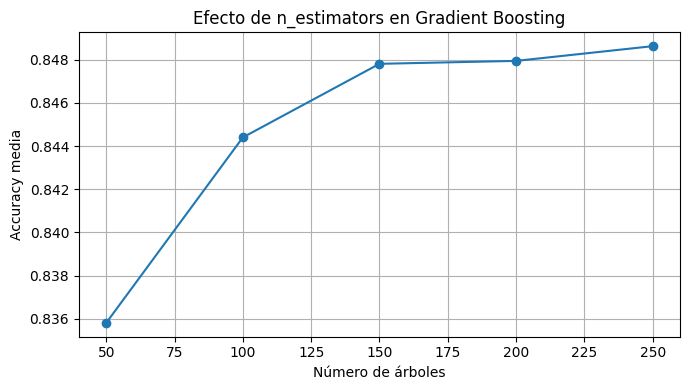

In [58]:
estimators = [50, 100, 150, 200, 250]
scores_estimators = []

for n in estimators:

    model = Pipeline([
        ("preprocessor", preprocessor_gb),
        ("clf", GradientBoostingClassifier(
            n_estimators=n,
            learning_rate=0.1,
            max_depth=3,
            random_state=SEED
        ))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    scores_estimators.append(score.mean())

plt.figure(figsize=(7, 4))
plt.plot(estimators, scores_estimators, marker="o")
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy media")
plt.title("Efecto de n_estimators en Gradient Boosting")
plt.grid(True)
plt.tight_layout()
plt.show()

## Importancia de variables

In [59]:
best_gb = grid_gb.best_estimator_
best_gb.fit(X_train, y_train)

feature_names = best_gb.named_steps["preprocessor"].get_feature_names_out()
importances = best_gb.named_steps["clf"].feature_importances_

importance_df_gb = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df_gb.head(10)

,Feature,Importance
3,num__duration,0.487431
51,cat__poutcome_success,0.092078
36,cat__contact_unknown,0.070205
5,num__pdays,0.042329
23,cat__marital_None,0.036840
31,cat__housing_yes,0.036701
2,num__day,0.034773
44,cat__month_mar,0.030678
0,num__age,0.022817
47,cat__month_oct,0.017208


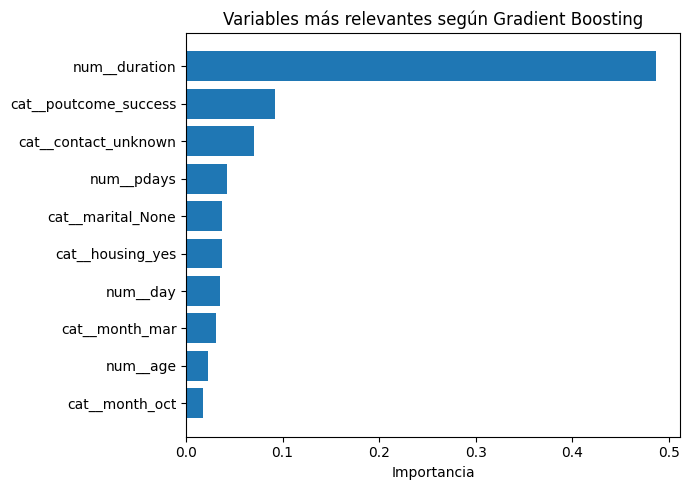

In [60]:
top_gb = importance_df_gb.head(10)

plt.figure(figsize=(7, 5))
plt.barh(top_gb["Feature"], top_gb["Importance"])
plt.gca().invert_yaxis()
plt.title("Variables más relevantes según Gradient Boosting")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

En las figuras anteriores se muestran las 10 variables más relevantes según el modelo de Gradient Boosting optimizado.

Los resultados indican que la variable `duration` es, con diferencia, la más influyente en la predicción, con una importancia aproximada de 0.49. Este resultado es coherente con lo observado en otros modelos analizados previamente, como el árbol de decisión, donde duration también aparecía como una de las variables principales en las primeras divisiones del árbol.

En conjunto, los resultados muestran que el modelo combina información de la interacción con el cliente (`duration`, `pdays`, `contact`), historial de campañas previas (`poutcome`) y características demográficas o temporales para realizar las predicciones.

El hecho de que varias de estas variables coincidan con las identificadas anteriormente en modelos como regresión logística o árboles de decisión refuerza la consistencia del análisis realizado a lo largo de la práctica.

## 7.3 Conclusiones tras análisis global

In [61]:
global_summary = pd.DataFrame({
    "Modelo": [
        "Dummy",
        "KNN (default)",
        "KNN optimizado",
        "Decision Tree (default)",
        "Decision Tree optimizado",
        "Logistic Regression (HPO)",
        "SVM (default)",
        "SVM (HPO)",
        "Gradient Boosting (default)",
        "Gradient Boosting (HPO)",
        "Gradient Boosting (early stopping)"
    ],

    "Accuracy CV": [
        dummy_scores.mean(),
        knn_scores.mean(),
        grid_knn.best_score_,
        tree_scores.mean(),
        grid_tree.best_score_,
        grid_logreg.best_score_,
        svm_scores.mean(),
        grid_svm.best_score_,
        gb_scores.mean(),
        grid_gb.best_score_,
        gb_early_scores.mean()
    ],

    "Training time (s)": [
        dummy_time,
        knn_time,
        knn_hpo_time,
        tree_time,
        tree_hpo_time,
        logreg_hpo_time,
        svm_time,
        svm_hpo_time,
        gb_time,
        gb_hpo_time,
        gb_early_time
    ]
})

global_summary["Accuracy CV"] = global_summary["Accuracy CV"].round(3)
global_summary["Training time (s)"] = global_summary["Training time (s)"].round(2)

global_summary = global_summary.sort_values("Accuracy CV", ascending=False).reset_index(drop=True)

global_summary

,Modelo,Accuracy CV,Training time (s)
0,Gradient Boosting (HPO),0.848,6.43
1,SVM (default),0.847,0.81
2,SVM (HPO),0.847,23.44
3,Gradient Boosting (default),0.844,0.86
4,Gradient Boosting (early stopping),0.840,1.00
5,Logistic Regression (HPO),0.828,0.24
6,Decision Tree optimizado,0.817,1.29
7,KNN optimizado,0.803,1.97
8,KNN (default),0.800,0.09
9,Decision Tree (default),0.777,0.09


Esta tarea adicional nos ha mostrado que Gradient Boosting ofrece un buen equilibrio entre rendimiento y coste computacional, ya que logra una accuracy algo superior (la mayor entre todos los modelos evaluados en la práctica) con un tiempo de entrenamiento mucho menor que SVM con HPO. Mientras que el modelo de Gradient Boosting con early stopping permite reducir el tiempo de entrenamiento, aunque en este caso se observa una leve disminución del rendimiento predictivo.

Los resultados obtenidos muestran que este tipo de modelos pueden alcanzar un rendimiento muy competitivo en nuestro problema de predecir si un cliente bancario suscribirá un depósito a plazo.

No obstante, también podemos observar que **SVM con hiperparámetros por defecto** alcanza un rendimiento casi igual que Gradient Boosting HPO, pero con un tiempo de entrenamiento mucho menor. Por tanto, Gradient Boosting sería una alternativa muy potente, aunque el análisis comparativo muestra que diferentes modelos pueden ofrecer soluciones similares dependiendo del equilibrio deseado entre rendimiento y coste computacional.

# 🧠 Utilización de IA

Durante la realización de esta práctica hemos utilizado la herramienta de inteligencia artificial ChatGPT como apoyo puntual para resolver dudas técnicas, depurar errores y aclarar algunos conceptos relacionados con la implementación y el análisis de los modelos.

En las primeras fases de la práctica, la herramienta se utilizó para orientar la estructura general del cuaderno, ya que inicialmente no teníamos claro cómo organizar el desarrollo del EDA y los distintos apartados del análisis. En concreto, se consultó para obtener una posible estructura de secciones que posteriormente adaptamos siguiendo la teoría y los tutoriales vistos en clase.

A continuación se detallan los principales usos de la herramienta durante el desarrollo de la práctica.

**Visualización de resultados**

Se consultó cómo representar algunos resultados de forma clara, especialmente en las primeras fases del EDA, como la visualización de la cardinalidad de variables categóricas, las dimensiones del dataset o la construcción de tablas resumen.


**Depuración de errores**

Durante el desarrollo del notebook se utilizó la herramienta para identificar y resolver errores de ejecución relacionados con el uso de pipelines, tipos de datos en pandas, manejo de valores NaN o incompatibilidades entre transformadores de scikit-learn. En algunos casos los errores se debían a pequeños detalles de implementación, como la falta de ciertos imports o parámetros mal definidos.

**Preparación de datos y preprocesamiento**

Se consultó la herramienta para resolver dudas relacionadas con el manejo de valores faltantes, la creación de variables derivadas (por ejemplo, la variable contacted_before a partir de pdays) y la correcta construcción de pipelines de preprocesamiento utilizando ColumnTransformer, SimpleImputer, StandardScaler y OneHotEncoder.

**Evaluación de modelos**

La herramienta se utilizó para aclarar dudas sobre la estrategia de evaluación empleada en la práctica, incluyendo la división de los datos en train/test mediante holdout, el uso de validación cruzada estratificada, y la correcta utilización de cross_val_score para estimar el rendimiento de los modelos.

**Implementación de pipelines**

Se realizaron consultas para comprobar que la integración del preprocesamiento y los modelos dentro de pipelines de scikit-learn era correcta y evitaba posibles problemas de data leakage durante la validación cruzada.

**Ajuste de hiperparámetros**

Se consultó la herramienta para resolver dudas sobre la implementación de GridSearchCV y la elección de rangos razonables de hiperparámetros para algunos modelos.

**Interpretación de modelos**

La herramienta también se utilizó para comprender mejor la interpretación de los coeficientes de la regresión logística, el efecto de la regularización L1 sobre dichos coeficientes y la identificación de variables relevantes a partir de estos resultados. Asimismo, se realizaron consultas puntuales para confirmar si ciertos comportamientos observados en los modelos (por ejemplo, que la optimización del parámetro de regularización en la regresión logística no produjera mejoras significativas en el rendimiento) eran esperables.


No hemos incluido una celda específica de declaración en cada sección del notebook porque consideramos que resultaría repetitivo y podría interrumpir el flujo de lectura del cuaderno. No obstante, declaramos explícitamente que la IA se ha utilizado únicamente como herramienta complementaria de consulta, mientras que el diseño del análisis, la implementación final del código, la ejecución de los experimentos y la interpretación de los resultados han sido realizados por nosotras. El desarrollo de la práctica se ha basado principalmente en la teoría y los tutoriales vistos en clase.

# Predicción para la comparación

In [65]:
import pandas as pd
import numpy as np
import joblib

modelo_final = joblib.load("modelo_final.joblib")

instancias_demo = pd.DataFrame([
    {
        "age": 35,
        "job": "technician",
        "marital": "single",
        "education": "tertiary",
        "default": "no",
        "balance": 1500,
        "housing": "yes",
        "loan": "no",
        "contact": "cellular",
        "day": 12,
        "month": "may",
        "duration": 320,
        "campaign": 2,
        "pdays": np.nan,
        "previous": 0,
        "poutcome": "unknown",
        "contacted_before": 0
    },
    {
        "age": 52,
        "job": "management",
        "marital": "married",
        "education": "secondary",
        "default": "no",
        "balance": 300,
        "housing": "no",
        "loan": "no",
        "contact": "telephone",
        "day": 8,
        "month": "oct",
        "duration": 120,
        "campaign": 1,
        "pdays": 15,
        "previous": 2,
        "poutcome": "success",
        "contacted_before": 1
    }
])

instancias_demo["prediccion"] = modelo_final.predict(instancias_demo)
instancias_demo

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,contacted_before,prediccion
0,35,technician,single,tertiary,no,1500,yes,no,cellular,12,may,320,2,NaN,0,unknown,0,0
1,52,management,married,secondary,no,300,no,no,telephone,8,oct,120,1,15.0,2,success,1,1
